## Preparação do ambiente e carregamento dos experimentos

Clonagem do repositório do GitHub

In [1]:
%cd /content
!git clone https://github.com/amartinsmg/classification-of-medical-images-using-cnn.git
%cd /content/classification-of-medical-images-using-cnn

/content
fatal: destination path 'classification-of-medical-images-using-cnn' already exists and is not an empty directory.
/content/classification-of-medical-images-using-cnn


Montagem do Google Drive

In [2]:
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Definição dos:
- Nomes dos experimentos analisados para cada arquitetura base
- Caminho relativo do diretório onde as comparações serão salvas
- Caminho da pasta onde os resultados dos modelos estão salvos no Google Drive
- Caminho da pasta onde as comparações serão no Google Drive

In [3]:
efficientnet_best_auc_exps = ["efficientnet-best-auc-1e-3", "efficientnet-best-auc-3e-4", "efficientnet-best-auc-1e-4"]
efficientnet_best_cm_exps = ["efficientnet-best-cm-1e-3", "efficientnet-best-cm-3e-4", "efficientnet-best-cm-1e-4"]
densenet_best_auc_exps = ["densenet-best-auc-1e-3", "densenet-best-auc-3e-4", "densenet-best-auc-1e-4"]
densenet_best_cm_exps = ["densenet-best-cm-1e-3", "densenet-best-cm-3e-4", "densenet-best-cm-1e-4"]
resnet_best_auc_exps = ["resnet-best-auc-1e-3", "resnet-best-auc-3e-4", "resnet-best-auc-1e-4"]
resnet_best_cm_exps = ["resnet-best-cm-1e-3", "resnet-best-cm-3e-4", "resnet-best-cm-1e-4"]

experiment_names = [*resnet_best_auc_exps, *densenet_best_auc_exps, *efficientnet_best_auc_exps,
                    *resnet_best_cm_exps, *densenet_best_cm_exps, *efficientnet_best_cm_exps]

COMPARISON_PATH = "comparisons/05-learning-rate"
RESULT_PATH = BASE_PATH + "results"
SAVE_DIR = BASE_PATH + COMPARISON_PATH

Carregamento dos experimentos

In [4]:
from src.analyses import load_experiments

experiments = load_experiments(RESULT_PATH, experiment_names)


## Visualização das métricas finais com média e desvio padrão

In [5]:
from src.analyses import metrics_table
from IPython.display import display

metrics = metrics_table(experiments)
display(metrics)

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
resnet-best-auc-1e-3,0.809295,0.020144,0.770464,0.021792,0.991453,0.005269,0.866860,0.011699,0.505698,0.062451,0.963566,0.003803
resnet-best-auc-3e-4,0.809295,0.020144,0.770464,0.021792,0.991453,0.005269,0.866860,0.011699,0.505698,0.062451,0.963566,0.003803
resnet-best-auc-1e-4,0.808226,0.018704,0.768948,0.019748,0.992308,0.004187,0.866276,0.010908,0.501425,0.056730,0.963535,0.003811
densenet-best-auc-1e-3,0.819979,0.056270,0.788886,0.064417,0.985470,0.015432,0.874262,0.033387,0.544160,0.174756,0.962950,0.003478
densenet-best-auc-3e-4,0.819979,0.056270,0.788886,0.064417,0.985470,0.015432,0.874262,0.033387,0.544160,0.174756,0.962950,0.003478
densenet-best-auc-1e-4,0.819979,0.056270,0.788886,0.064417,0.985470,0.015432,0.874262,0.033387,0.544160,0.174756,0.962950,0.003478
efficientnet-best-auc-1e-3,0.844551,0.004533,0.806372,0.007254,0.988889,0.004835,0.888310,0.002421,0.603989,0.020145,0.969923,0.001793
efficientnet-best-auc-3e-4,0.844551,0.004533,0.806372,0.007254,0.988889,0.004835,0.888310,0.002421,0.603989,0.020145,0.969923,0.001793
efficientnet-best-auc-1e-4,0.844551,0.004533,0.806372,0.007254,0.988889,0.004835,0.888310,0.002421,0.603989,0.020145,0.969923,0.001793


## Visualização da comparação completa dos experimentos com ResNet (sem _data aug_ e sem _class weight_)

- Visualização das métricas finais com média e desvio padrão
- Visualização dos gráficos de treino/validação
- Visualização das curvas ROC dos experimentos
- Visualização da matriz de confusão de cada experimento

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
resnet-best-auc-1e-3,0.809295,0.020144,0.770464,0.021792,0.991453,0.005269,0.866860,0.011699,0.505698,0.062451,0.963566,0.003803
resnet-best-auc-3e-4,0.809295,0.020144,0.770464,0.021792,0.991453,0.005269,0.866860,0.011699,0.505698,0.062451,0.963566,0.003803
resnet-best-auc-1e-4,0.808226,0.018704,0.768948,0.019748,0.992308,0.004187,0.866276,0.010908,0.501425,0.056730,0.963535,0.003811


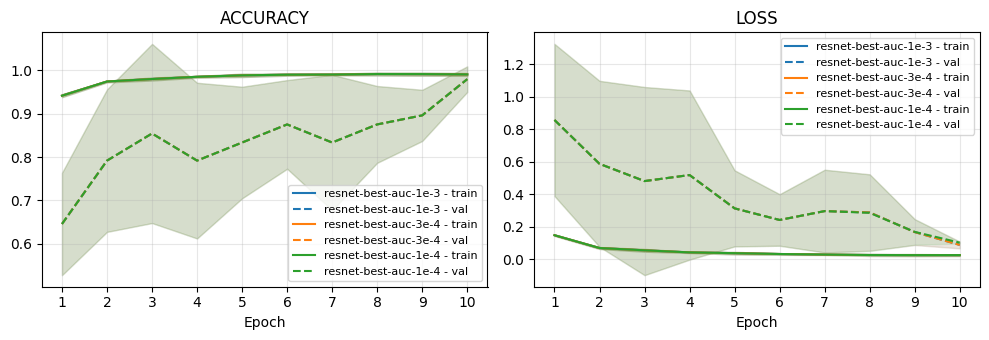

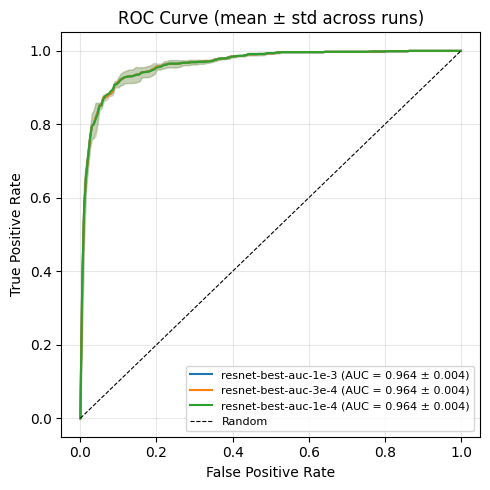

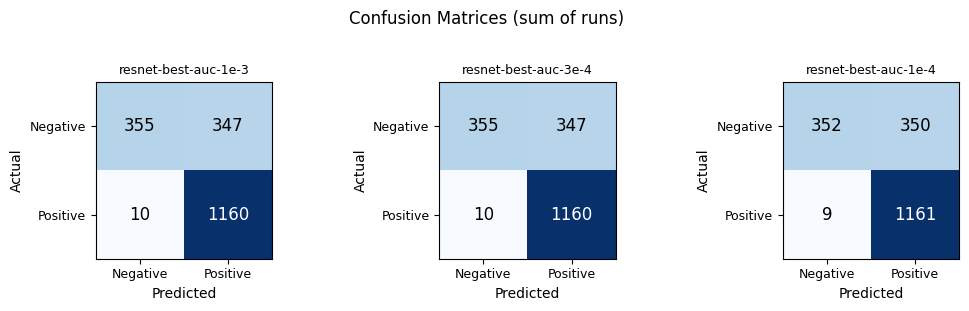

In [6]:
from src.analyses import full_comparison

_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=resnet_best_auc_exps,
  history_metrics=["accuracy", "loss"],
  show_plot=True,
)

## Visualização da comparação completa dos experimentos com ResNet (_data aug_ + _class weight_)

- Visualização das métricas finais com média e desvio padrão
- Visualização dos gráficos de treino/validação
- Visualização das curvas ROC dos experimentos
- Visualização da matriz de confusão de cada experimento

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
resnet-best-cm-1e-3,0.889423,0.012619,0.914868,0.030792,0.910256,0.041239,0.911215,0.011472,0.854701,0.062904,0.956834,0.003682
resnet-best-cm-3e-4,0.889423,0.012619,0.914868,0.030792,0.910256,0.041239,0.911215,0.011472,0.854701,0.062904,0.956834,0.003682
resnet-best-cm-1e-4,0.889423,0.012619,0.914868,0.030792,0.910256,0.041239,0.911215,0.011472,0.854701,0.062904,0.956834,0.003682


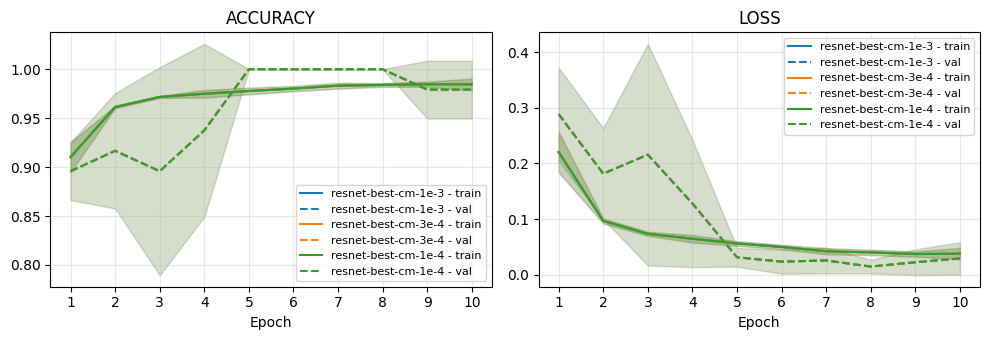

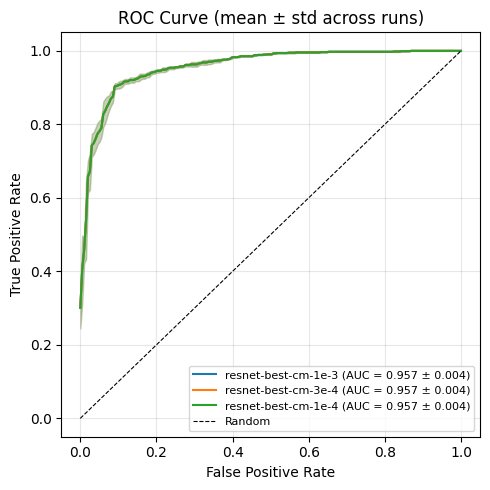

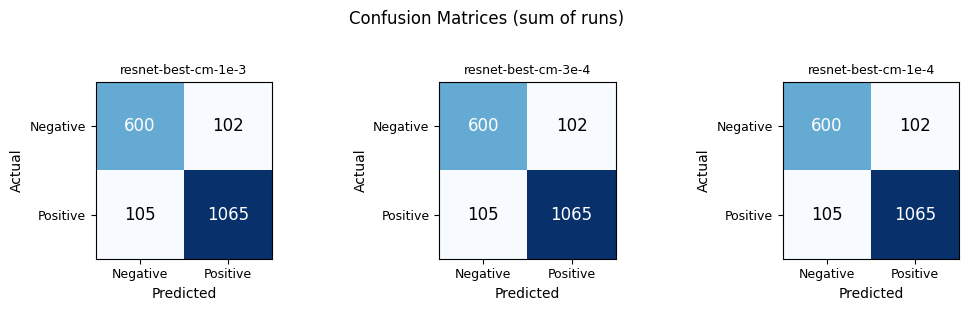

In [7]:
_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=resnet_best_cm_exps,
  history_metrics=["accuracy", "loss"],
  show_plot=True,
)

## Visualização da comparação completa dos experimentos com DenseNet (sem _data aug_ e sem _class weight_)

- Visualização das métricas finais com média e desvio padrão
- Visualização dos gráficos de treino/validação
- Visualização das curvas ROC dos experimentos
- Visualização da matriz de confusão de cada experimento

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
densenet-best-auc-1e-3,0.819979,0.05627,0.788886,0.064417,0.98547,0.015432,0.874262,0.033387,0.54416,0.174756,0.96295,0.003478
densenet-best-auc-3e-4,0.819979,0.05627,0.788886,0.064417,0.98547,0.015432,0.874262,0.033387,0.54416,0.174756,0.96295,0.003478
densenet-best-auc-1e-4,0.819979,0.05627,0.788886,0.064417,0.98547,0.015432,0.874262,0.033387,0.54416,0.174756,0.96295,0.003478


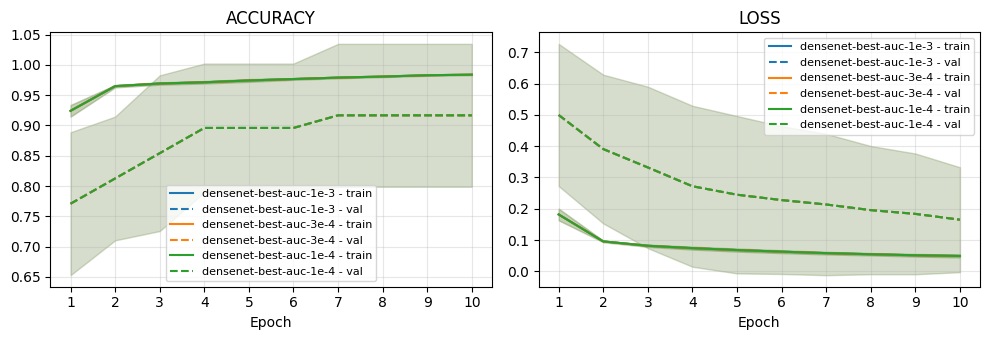

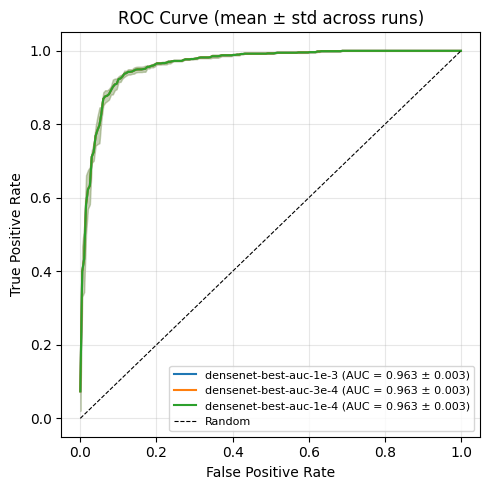

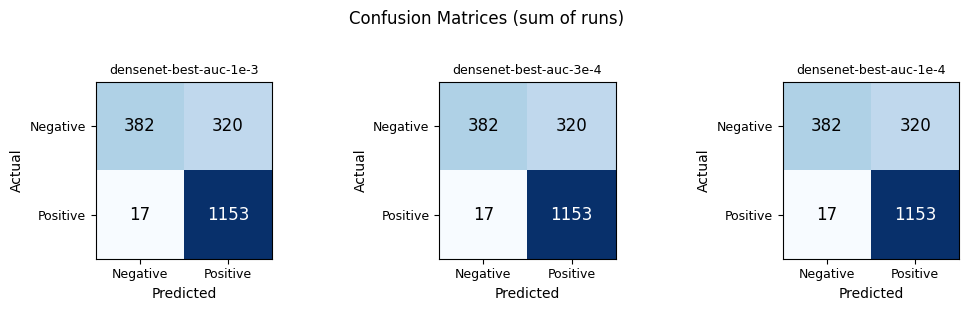

In [8]:
_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=densenet_best_auc_exps,
  history_metrics=["accuracy", "loss"],
  show_plot=True,
)

## Visualização da comparação completa dos experimentos com DenseNet (_data aug_ + _class weight_)

- Visualização das métricas finais com média e desvio padrão
- Visualização dos gráficos de treino/validação
- Visualização das curvas ROC dos experimentos
- Visualização da matriz de confusão de cada experimento

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
densenet-best-cm-1e-3,0.880876,0.009994,0.86972,0.02549,0.953846,0.018842,0.909299,0.005391,0.759259,0.057793,0.956323,0.000575
densenet-best-cm-3e-4,0.880876,0.009994,0.86972,0.02549,0.953846,0.018842,0.909299,0.005391,0.759259,0.057793,0.956323,0.000575
densenet-best-cm-1e-4,0.880876,0.009994,0.86972,0.02549,0.953846,0.018842,0.909299,0.005391,0.759259,0.057793,0.956323,0.000575


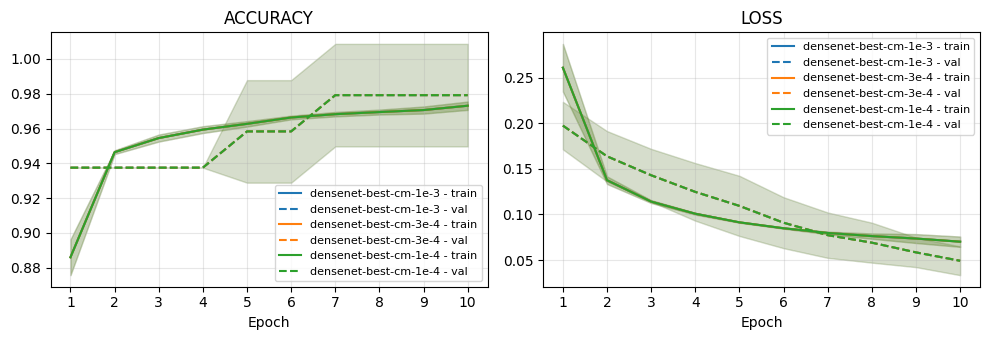

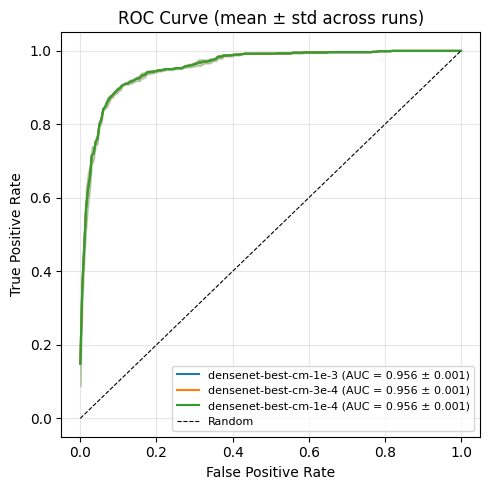

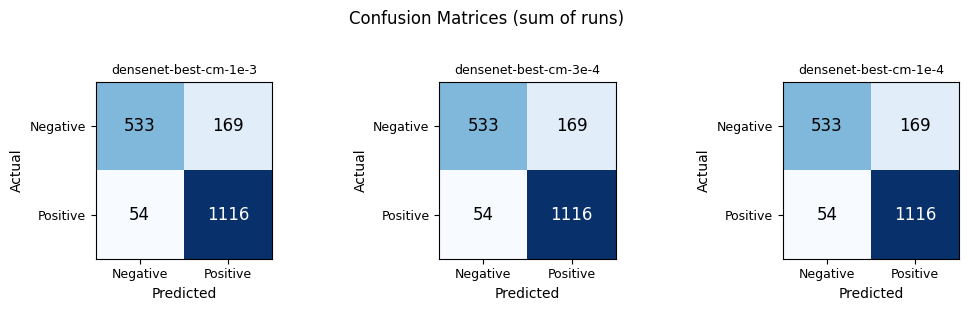

In [9]:
_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=densenet_best_cm_exps,
  history_metrics=["accuracy", "loss"],
  show_plot=True,
)

## Visualização da comparação completa dos experimentos com EfficientNet (somente _class weight_)

- Visualização das métricas finais com média e desvio padrão
- Visualização dos gráficos de treino/validação
- Visualização das curvas ROC dos experimentos
- Visualização da matriz de confusão de cada experimento

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
efficientnet-best-auc-1e-3,0.844551,0.004533,0.806372,0.007254,0.988889,0.004835,0.88831,0.002421,0.603989,0.020145,0.969923,0.001793
efficientnet-best-auc-3e-4,0.844551,0.004533,0.806372,0.007254,0.988889,0.004835,0.88831,0.002421,0.603989,0.020145,0.969923,0.001793
efficientnet-best-auc-1e-4,0.844551,0.004533,0.806372,0.007254,0.988889,0.004835,0.88831,0.002421,0.603989,0.020145,0.969923,0.001793


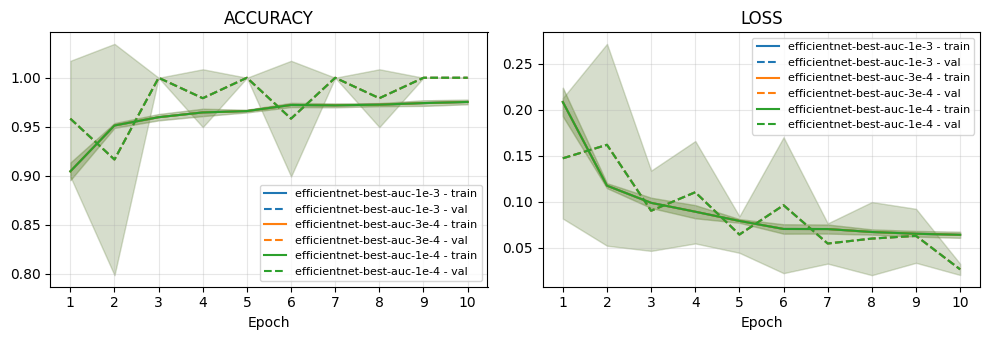

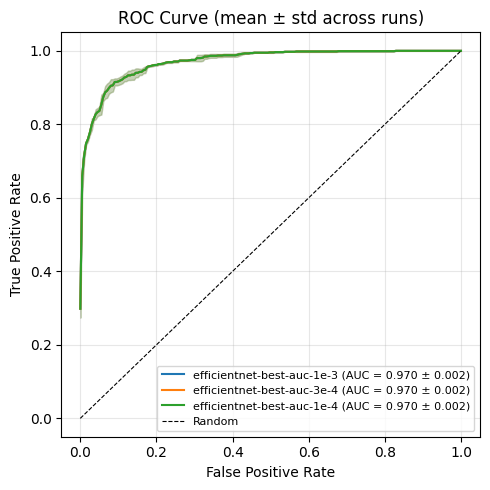

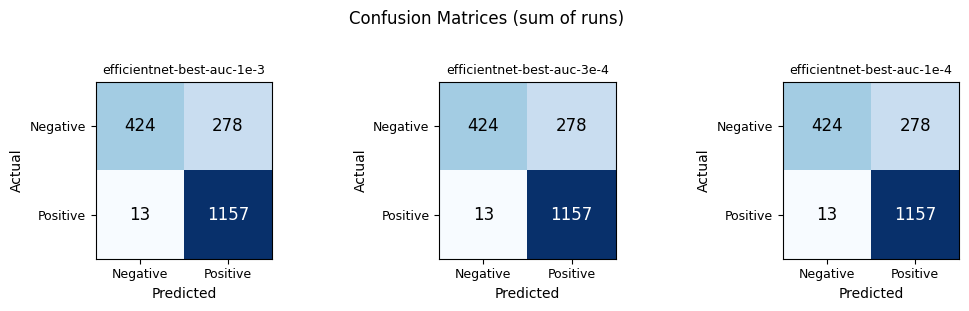

In [10]:
_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=efficientnet_best_auc_exps,
  history_metrics=["accuracy", "loss"],
  show_plot=True,
)

## Visualização da comparação completa dos experimentos com EfficientNet (_data aug_ + _class weight_)

- Visualização das métricas finais com média e desvio padrão
- Visualização dos gráficos de treino/validação
- Visualização das curvas ROC dos experimentos
- Visualização da matriz de confusão de cada experimento

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
efficientnet-best-cm-1e-3,0.880876,0.011281,0.879516,0.044861,0.94359,0.039943,0.908458,0.004914,0.776353,0.094941,0.961739,0.000533
efficientnet-best-cm-3e-4,0.880876,0.011281,0.879516,0.044861,0.94359,0.039943,0.908458,0.004914,0.776353,0.094941,0.961739,0.000533
efficientnet-best-cm-1e-4,0.880876,0.011281,0.879516,0.044861,0.94359,0.039943,0.908458,0.004914,0.776353,0.094941,0.961739,0.000533


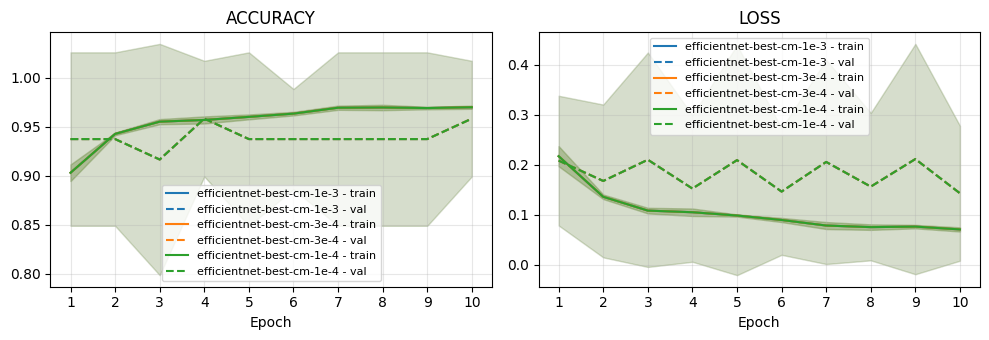

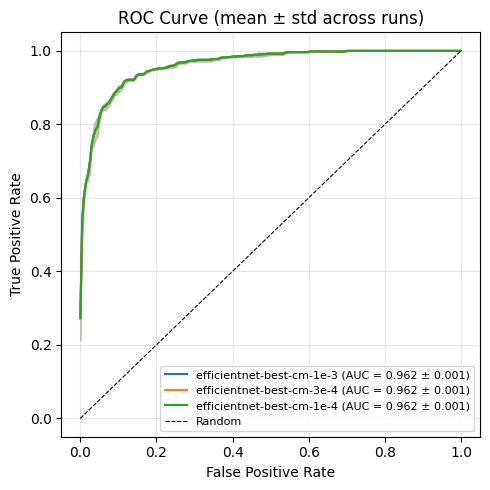

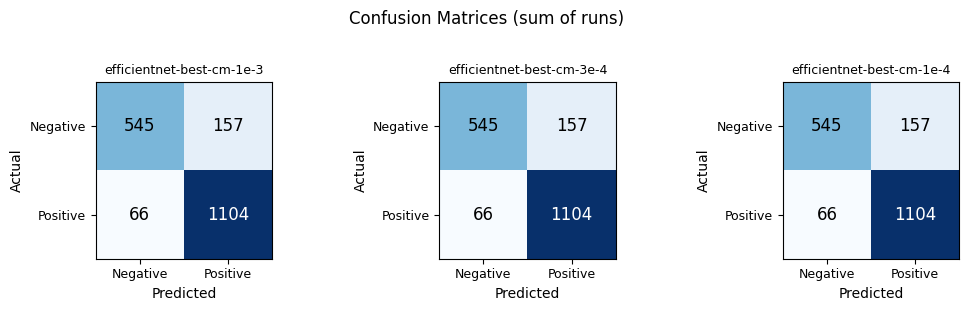

In [11]:
_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=efficientnet_best_cm_exps,
  history_metrics=["accuracy", "loss"],
  show_plot=True,
)

## Salvamento da comparação completa

A comparação completa é salva no Google Drive

In [12]:
from src.analyses import full_comparison

_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=experiment_names,
  history_metrics=["accuracy", "loss"],
  show_plot=False,
  save_dir=SAVE_DIR,
  separe_archs=True
)

/content/classification-of-medical-images-using-cnn/src/analyses.py:258: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()



Results saved in /content/drive/MyDrive/classification-of-medical-images-using-cnn/comparisons/05-learning-rate


Upload da tabela e dos gráficos para o DagsHub

In [ ]:
%pip install -q dvc dagshub

import dagshub
from google.colab import userdata

dagshub.auth.add_app_token(token=userdata.get("DAGSHUB_TOKEN"))

DAGSHUB_REPO = "amartinsmg/classification-of-medical-images-using-cnn"

dagshub.upload_files(
    DAGSHUB_REPO,
    local_path=SAVE_DIR,
    remote_path=COMPARISON_PATH,
    force=True
)

Accessing as amartinsmg

Output()

Directory upload complete, uploaded 13 files to 
https://dagshub.com/amartinsmg/classification-of-medical-images-using-cnn/src/main/comparisons%2F05-learning-rate